# Crypto Sell-Off Mean Reversion Backtest

## Project Overview

This project extends the previous Crypto Sell-Off Mean Reversion Study by converting the event-study findings into a simple rules-based backtest.

The strategy tests whether buying BTC, ETH or SOL after a large daily sell-off would have produced attractive historical returns after transaction costs and drawdowns.

## Research Question

If an investor bought BTC, ETH or SOL after a daily sell-off of 10% or more, would the strategy have produced attractive historical returns across different holding periods?

## Strategy Rules

- A buy signal occurs when the asset falls by 10% or more in one day.
- The strategy enters at the daily close after the sell-off.
- The strategy exits after a fixed holding period.
- The holding periods tested are 1 day, 3 days, 7 days and 30 days.
- The strategy avoids overlapping trades.
- A transaction cost is applied to each trade.
- The starting portfolio value is set at £10,000.

## Important Note

This is a historical and educational backtest. It is not financial advice. The results do not guarantee future performance.

In [ ]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## Backtest Setup

This section defines the assets, starting capital, transaction costs and holding periods used in the backtest.

In [3]:
assets = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD"
}

start_date = "2017-01-01"
starting_capital = 10000
selloff_threshold = -0.10
transaction_cost_per_side = 0.001
total_transaction_cost = transaction_cost_per_side * 2

holding_periods = [1, 3, 7, 30]

## Data Download And Feature Creation

This section downloads daily price data and calculates daily returns, the 50-day moving average and whether the asset is above its 50-day moving average.

In [4]:
def download_and_prepare_data(ticker, start_date):
    data = yf.download(ticker, start=start_date)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data["Daily Return"] = data["Close"].pct_change()
    data["50D Moving Average"] = data["Close"].rolling(window=50).mean()
    data["Above 50D Moving Average"] = data["Close"] > data["50D Moving Average"]

    return data

In [ ]:
asset_data = {}

for asset_name, ticker in assets.items():
    asset_data[asset_name] = download_and_prepare_data(ticker, start_date)

## Backtest Function

This function runs a simple rules-based backtest.

The strategy buys after a daily sell-off of 10% or more and exits after a fixed holding period. Trades are non-overlapping, meaning the strategy does not open a new trade while another trade is already active.

In [6]:
def run_selloff_backtest(data, holding_period, use_trend_filter=False):
    trades = []
    i = 0

    while i < len(data) - holding_period:
        current_row = data.iloc[i]

        selloff_signal = current_row["Daily Return"] <= selloff_threshold

        if use_trend_filter:
            trend_condition = current_row["Above 50D Moving Average"] == True
        else:
            trend_condition = True

        if selloff_signal and trend_condition:
            entry_date = data.index[i]
            exit_date = data.index[i + holding_period]

            signal_day_return = current_row["Daily Return"]
            entry_price = data.iloc[i]["Close"]
            exit_price = data.iloc[i + holding_period]["Close"]

            gross_return = (exit_price / entry_price) - 1
            net_return = gross_return - total_transaction_cost

            trades.append({
                "Entry Date": entry_date,
                "Exit Date": exit_date,
                "Signal Day Return": signal_day_return,
                "Entry Price": entry_price,
                "Exit Price": exit_price,
                "Gross Return": gross_return,
                "Net Return": net_return
            })

            i += holding_period
        else:
            i += 1

    trades_df = pd.DataFrame(trades)

    if len(trades_df) == 0:
        return trades_df

    trades_df["Portfolio Value"] = starting_capital * (1 + trades_df["Net Return"]).cumprod()
    trades_df["Cumulative Return"] = trades_df["Portfolio Value"] / starting_capital - 1
    trades_df["Running Peak"] = trades_df["Portfolio Value"].cummax().clip(lower=starting_capital)
    trades_df["Drawdown"] = trades_df["Portfolio Value"] / trades_df["Running Peak"] - 1

    return trades_df

## Performance Summary Function

This function summarises the performance of each backtest by calculating total return, win rate, average trade return, worst trade, best trade and maximum drawdown.

In [7]:
def summarise_backtest(trades_df):
    if len(trades_df) == 0:
        return {
            "Number Of Trades": 0,
            "Final Portfolio Value": None,
            "Total Return": None,
            "Win Rate": None,
            "Average Trade Return": None,
            "Worst Trade": None,
            "Best Trade": None,
            "Maximum Drawdown": None
        }

    final_portfolio_value = trades_df["Portfolio Value"].iloc[-1]
    total_return = final_portfolio_value / starting_capital - 1
    win_rate = (trades_df["Net Return"] > 0).mean()
    average_trade_return = trades_df["Net Return"].mean()
    worst_trade = trades_df["Net Return"].min()
    best_trade = trades_df["Net Return"].max()
    maximum_drawdown = trades_df["Drawdown"].min()

    return {
        "Number Of Trades": len(trades_df),
        "Final Portfolio Value": final_portfolio_value,
        "Total Return": total_return,
        "Win Rate": win_rate,
        "Average Trade Return": average_trade_return,
        "Worst Trade": worst_trade,
        "Best Trade": best_trade,
        "Maximum Drawdown": maximum_drawdown
    }

## Running The Backtests

This section runs the strategy across BTC, ETH and SOL using 1-day, 3-day, 7-day and 30-day holding periods.

In [8]:
backtest_results = []
trade_logs = {}

for asset_name, data in asset_data.items():
    for holding_period in holding_periods:
        trades = run_selloff_backtest(
            data=data,
            holding_period=holding_period,
            use_trend_filter=False
        )

        trade_logs[(asset_name, holding_period, "No Trend Filter")] = trades

        summary = summarise_backtest(trades)
        summary["Asset"] = asset_name
        summary["Holding Period"] = holding_period
        summary["Trend Filter"] = "No"

        backtest_results.append(summary)

backtest_summary = pd.DataFrame(backtest_results)

In [9]:
backtest_summary_display = backtest_summary.copy()

percentage_columns = [
    "Total Return",
    "Win Rate",
    "Average Trade Return",
    "Worst Trade",
    "Best Trade",
    "Maximum Drawdown"
]

for column in percentage_columns:
    backtest_summary_display[column] = backtest_summary_display[column] * 100

backtest_summary_display = backtest_summary_display.round(2)

backtest_summary_display

,Number Of Trades,Final Portfolio Value,Total Return,Win Rate,Average Trade Return,Worst Trade,Best Trade,Maximum Drawdown,Asset,Holding Period,Trend Filter
0,35,19512.90,95.13,68.57,2.15,-14.55,15.10,-17.95,BTC,1,No
1,32,14283.72,42.84,56.25,1.48,-12.82,18.64,-22.10,BTC,3,No
2,28,10024.64,0.25,57.14,1.13,-24.92,40.39,-46.24,BTC,7,No
3,23,38932.01,289.32,47.83,10.52,-24.24,116.18,-56.02,BTC,30,No
4,59,20808.32,108.08,59.32,1.50,-17.66,18.36,-37.76,ETH,1,No
5,52,14574.00,45.74,53.85,1.24,-23.99,23.88,-38.33,ETH,3,No
6,47,4405.07,-55.95,38.30,-0.80,-37.81,27.73,-64.86,ETH,7,No
7,32,1172.80,-88.27,34.38,-3.97,-53.72,59.80,-93.45,ETH,30,No
8,68,22189.94,121.90,58.82,2.02,-42.48,47.08,-57.52,SOL,1,No
9,58,53090.04,430.90,65.52,4.35,-57.55,51.77,-59.51,SOL,3,No


## Running The Backtests With The 50-Day Moving Average Filter

This section repeats the backtest, but only takes sell-off signals when the asset remains above its 50-day moving average.

In [10]:
trend_filter_results = []

for asset_name, data in asset_data.items():
    for holding_period in holding_periods:
        trades = run_selloff_backtest(
            data=data,
            holding_period=holding_period,
            use_trend_filter=True
        )

        trade_logs[(asset_name, holding_period, "50D Trend Filter")] = trades

        summary = summarise_backtest(trades)
        summary["Asset"] = asset_name
        summary["Holding Period"] = holding_period
        summary["Trend Filter"] = "Yes"

        trend_filter_results.append(summary)

trend_filter_summary = pd.DataFrame(trend_filter_results)

In [11]:
trend_filter_summary_display = trend_filter_summary.copy()

for column in percentage_columns:
    trend_filter_summary_display[column] = trend_filter_summary_display[column] * 100

trend_filter_summary_display = trend_filter_summary_display.round(2)

trend_filter_summary_display

,Number Of Trades,Final Portfolio Value,Total Return,Win Rate,Average Trade Return,Worst Trade,Best Trade,Maximum Drawdown,Asset,Holding Period,Trend Filter
0,6,13722.33,37.22,83.33,5.50,-1.74,10.75,-1.74,BTC,1,Yes
1,6,10434.99,4.35,50.00,0.98,-7.53,15.47,-7.53,BTC,3,Yes
2,6,15121.35,51.21,83.33,7.82,-2.83,35.12,-2.83,BTC,7,Yes
3,5,13279.48,32.79,40.00,10.95,-16.33,81.79,-36.34,BTC,30,Yes
4,14,12930.29,29.30,57.14,1.97,-4.48,11.07,-5.60,ETH,1,Yes
5,14,10954.08,9.54,50.00,1.05,-9.32,23.88,-20.32,ETH,3,Yes
6,14,8421.87,-15.78,35.71,-0.18,-37.10,18.61,-44.41,ETH,7,Yes
7,13,5993.81,-40.06,30.77,-1.51,-30.44,59.80,-45.30,ETH,30,Yes
8,19,17735.38,77.35,68.42,3.58,-19.52,22.79,-26.06,SOL,1,Yes
9,18,15731.25,57.31,72.22,5.66,-57.55,51.77,-57.55,SOL,3,Yes


## Combined Strategy Comparison

This section combines the unfiltered and trend-filtered backtests into one comparison table.

In [12]:
combined_summary = pd.concat(
    [backtest_summary, trend_filter_summary],
    ignore_index=True
)

combined_summary_display = combined_summary.copy()

for column in percentage_columns:
    combined_summary_display[column] = combined_summary_display[column] * 100

combined_summary_display = combined_summary_display.round(2)

combined_summary_display

,Number Of Trades,Final Portfolio Value,Total Return,Win Rate,Average Trade Return,Worst Trade,Best Trade,Maximum Drawdown,Asset,Holding Period,Trend Filter
0,35,19512.90,95.13,68.57,2.15,-14.55,15.10,-17.95,BTC,1,No
1,32,14283.72,42.84,56.25,1.48,-12.82,18.64,-22.10,BTC,3,No
2,28,10024.64,0.25,57.14,1.13,-24.92,40.39,-46.24,BTC,7,No
3,23,38932.01,289.32,47.83,10.52,-24.24,116.18,-56.02,BTC,30,No
4,59,20808.32,108.08,59.32,1.50,-17.66,18.36,-37.76,ETH,1,No
5,52,14574.00,45.74,53.85,1.24,-23.99,23.88,-38.33,ETH,3,No
6,47,4405.07,-55.95,38.30,-0.80,-37.81,27.73,-64.86,ETH,7,No
7,32,1172.80,-88.27,34.38,-3.97,-53.72,59.80,-93.45,ETH,30,No
8,68,22189.94,121.90,58.82,2.02,-42.48,47.08,-57.52,SOL,1,No
9,58,53090.04,430.90,65.52,4.35,-57.55,51.77,-59.51,SOL,3,No


## Visualising Total Return By Strategy

This chart compares total returns across assets, holding periods and filter types.

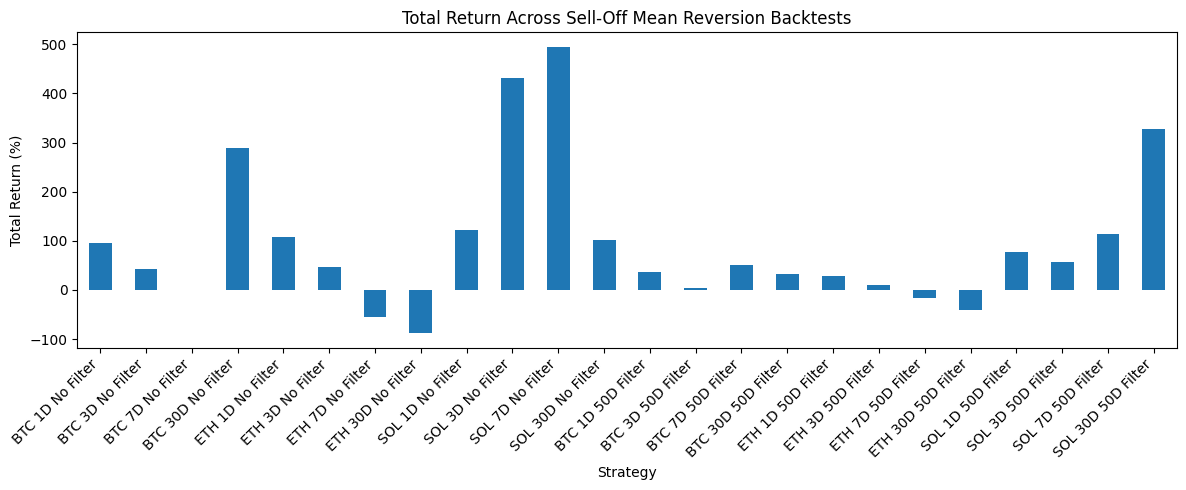

In [13]:
chart_data = combined_summary_display.copy()

chart_data["Strategy"] = (
    chart_data["Asset"] + " " +
    chart_data["Holding Period"].astype(str) + "D " +
    chart_data["Trend Filter"].map({"No": "No Filter", "Yes": "50D Filter"})
)

chart_data.set_index("Strategy")["Total Return"].plot(kind="bar", figsize=(12, 5))

plt.title("Total Return Across Sell-Off Mean Reversion Backtests")
plt.ylabel("Total Return (%)")
plt.xlabel("Strategy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualising Maximum Drawdown

This chart compares the maximum drawdown of each strategy. A larger negative drawdown indicates greater downside risk.

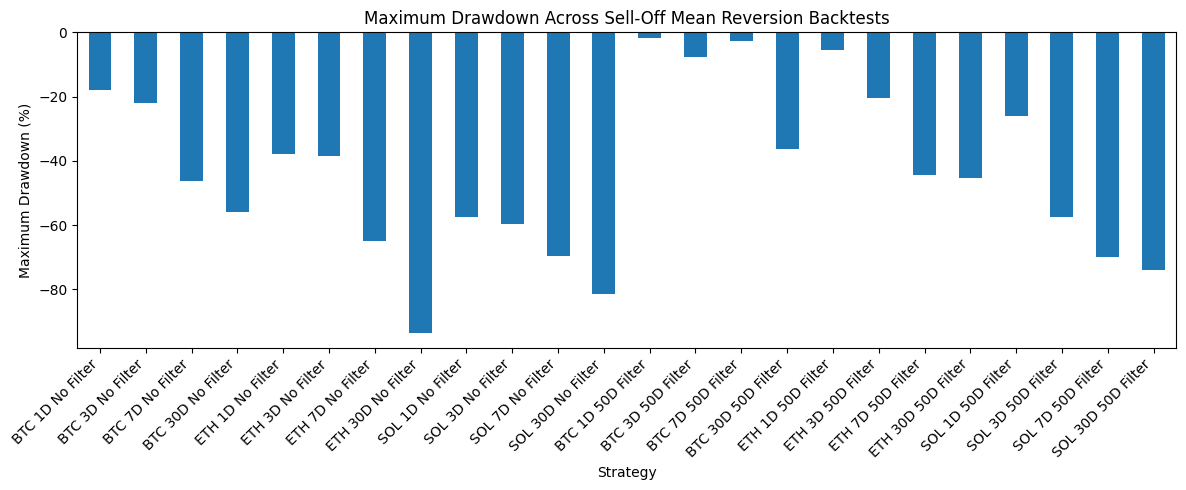

In [14]:
chart_data.set_index("Strategy")["Maximum Drawdown"].plot(kind="bar", figsize=(12, 5))

plt.title("Maximum Drawdown Across Sell-Off Mean Reversion Backtests")
plt.ylabel("Maximum Drawdown (%)")
plt.xlabel("Strategy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Initial Backtest Findings

The backtest results show that the sell-off mean-reversion strategy produced very different results across BTC, ETH and SOL.

BTC produced the cleanest short-term results. The 1-day BTC strategy generated a positive total return, a high win rate and a more controlled drawdown compared with the more volatile SOL strategies.

SOL produced the strongest total returns, especially over the 3-day, 7-day and 30-day holding periods. However, these stronger returns came with much larger drawdowns and more severe worst-trade outcomes. This suggests that SOL offered greater upside but also carried substantially higher risk.

ETH performed weakest under this framework. The longer holding-period ETH strategies produced negative total returns, suggesting that ETH sell-offs did not lead to reliable mean reversion under the rules tested in this backtest.

The 50-day moving average filter reduced the number of trades. In some cases, it improved the quality of signals, but it did not consistently improve performance across every asset and holding period.

Overall, the results suggest that sell-off mean reversion was most reliable for BTC over shorter horizons, while SOL produced the largest upside but with much greater downside risk.

## Example Trade Log

This section shows the individual trades for one example strategy: BTC with a 1-day holding period and no trend filter.

In [15]:
example_trade_log = trade_logs[("BTC", 1, "No Trend Filter")].head().copy()

trade_log_percentage_columns = [
    "Signal Day Return",
    "Gross Return",
    "Net Return",
    "Cumulative Return",
    "Drawdown"
]

for column in trade_log_percentage_columns:
    example_trade_log[column] = example_trade_log[column] * 100

example_trade_log.round(2)

,Entry Date,Exit Date,Signal Day Return,Entry Price,Exit Price,Gross Return,Net Return,Portfolio Value,Cumulative Return,Running Peak,Drawdown
0,2017-01-05,2017-01-06,-12.24,1013.38,902.20,-10.97,-11.17,8882.89,-11.17,10000.0,-11.17
1,2017-01-06,2017-01-07,-10.97,902.20,908.59,0.71,0.51,8927.98,-10.72,10000.0,-10.72
2,2017-01-11,2017-01-12,-14.31,777.76,804.83,3.48,3.28,9220.94,-7.79,10000.0,-7.79
3,2017-03-18,2017-03-19,-11.49,973.82,1036.74,6.46,6.26,9798.30,-2.02,10000.0,-2.02
4,2017-06-12,2017-06-13,-10.09,2659.63,2717.02,2.16,1.96,9990.13,-0.10,10000.0,-0.10


The example trade log shows how the backtest records individual trades. The signal day return confirms that each trade was triggered by a daily sell-off of 10% or more. The strategy then enters at the signal-day close and exits after the chosen holding period.

This table is included to make the backtest mechanics transparent. The main performance conclusions are based on the full strategy summary tables, drawdown analysis and benchmark comparison below.


## Buy-And-Hold Benchmark

A backtest should be compared against a simple benchmark. This section calculates what would have happened if an investor bought each asset at the first available price in the dataset and held it until the end of the sample period.

This helps assess whether the sell-off mean-reversion strategy added value compared with simply holding the asset.

In [16]:
def calculate_buy_and_hold_summary(data):
    clean_data = data.dropna(subset=["Close"]).copy()

    first_date = clean_data.index[0]
    last_date = clean_data.index[-1]

    first_close = clean_data["Close"].iloc[0]
    last_close = clean_data["Close"].iloc[-1]

    final_portfolio_value = starting_capital * (last_close / first_close)
    total_return = final_portfolio_value / starting_capital - 1

    equity_curve = starting_capital * (clean_data["Close"] / first_close)
    running_peak = equity_curve.cummax()
    drawdown = equity_curve / running_peak - 1
    maximum_drawdown = drawdown.min()

    return {
        "Start Date": first_date,
        "End Date": last_date,
        "Start Price": first_close,
        "End Price": last_close,
        "Final Portfolio Value": final_portfolio_value,
        "Total Return": total_return,
        "Maximum Drawdown": maximum_drawdown
    }

In [17]:
buy_and_hold_results = []

for asset_name, data in asset_data.items():
    summary = calculate_buy_and_hold_summary(data)
    summary["Asset"] = asset_name
    buy_and_hold_results.append(summary)

buy_and_hold_summary = pd.DataFrame(buy_and_hold_results)

In [18]:
buy_and_hold_display = buy_and_hold_summary.copy()

buy_and_hold_display["Total Return"] = buy_and_hold_display["Total Return"] * 100
buy_and_hold_display["Maximum Drawdown"] = buy_and_hold_display["Maximum Drawdown"] * 100

buy_and_hold_display = buy_and_hold_display.round(2)

buy_and_hold_display

,Start Date,End Date,Start Price,End Price,Final Portfolio Value,Total Return,Maximum Drawdown,Asset
0,2017-01-01,2026-06-12,998.33,63417.58,635239.80,6252.4,-83.40,BTC
1,2017-11-09,2026-06-12,320.88,1660.25,51739.88,417.4,-93.96,ETH
2,2020-04-10,2026-06-12,0.95,66.53,699539.67,6895.4,-96.27,SOL


## Risk-Adjusted Strategy Ranking

Total return alone does not show how risky a strategy was. This section adds a simple return-to-drawdown score, which compares total return with maximum drawdown.

A higher score suggests that the strategy generated more return for each unit of drawdown risk.

In [19]:
risk_adjusted_summary = combined_summary.copy()

risk_adjusted_summary["Return To Drawdown"] = (
    risk_adjusted_summary["Total Return"] / risk_adjusted_summary["Maximum Drawdown"].abs()
)

risk_adjusted_summary_display = risk_adjusted_summary.copy()

for column in percentage_columns:
    risk_adjusted_summary_display[column] = risk_adjusted_summary_display[column] * 100

risk_adjusted_summary_display = risk_adjusted_summary_display.round(2)

risk_adjusted_summary_display = risk_adjusted_summary_display.sort_values(
    by="Return To Drawdown",
    ascending=False
)

risk_adjusted_summary_display

,Number Of Trades,Final Portfolio Value,Total Return,Win Rate,Average Trade Return,Worst Trade,Best Trade,Maximum Drawdown,Asset,Holding Period,Trend Filter,Return To Drawdown
12,6,13722.33,37.22,83.33,5.50,-1.74,10.75,-1.74,BTC,1,Yes,21.42
14,6,15121.35,51.21,83.33,7.82,-2.83,35.12,-2.83,BTC,7,Yes,18.08
9,58,53090.04,430.90,65.52,4.35,-57.55,51.77,-59.51,SOL,3,No,7.24
10,48,59501.77,495.02,58.33,5.88,-59.92,67.30,-69.74,SOL,7,No,7.10
0,35,19512.90,95.13,68.57,2.15,-14.55,15.10,-17.95,BTC,1,No,5.30
16,14,12930.29,29.30,57.14,1.97,-4.48,11.07,-5.60,ETH,1,Yes,5.23
3,23,38932.01,289.32,47.83,10.52,-24.24,116.18,-56.02,BTC,30,No,5.16
23,12,42700.57,327.01,50.00,29.66,-56.48,197.69,-73.91,SOL,30,Yes,4.42
20,19,17735.38,77.35,68.42,3.58,-19.52,22.79,-26.06,SOL,1,Yes,2.97
4,59,20808.32,108.08,59.32,1.50,-17.66,18.36,-37.76,ETH,1,No,2.86


## Strategy Exposure And Time In Market

Raw returns should be interpreted alongside market exposure. Buy-and-hold is invested throughout the full sample period, while the sell-off mean-reversion strategy is only invested after specific signal events.

This section estimates the percentage of time each strategy was invested in the market. This helps explain why buy-and-hold can produce much higher raw returns, while the sell-off strategy behaves more like a tactical strategy with lower market exposure.

In [20]:
exposure_results = []

for asset_name, data in asset_data.items():
    clean_data = data.dropna(subset=["Close"]).copy()
    sample_start = clean_data.index[0]
    sample_end = clean_data.index[-1]
    total_sample_days = (sample_end - sample_start).days

    for holding_period in holding_periods:
        for filter_type in ["No Trend Filter", "50D Trend Filter"]:
            trades = trade_logs[(asset_name, holding_period, filter_type)]

            if len(trades) == 0:
                days_in_market = 0
                time_in_market = 0
            else:
                entry_dates = pd.to_datetime(trades["Entry Date"])
                exit_dates = pd.to_datetime(trades["Exit Date"])
                days_in_market = (exit_dates - entry_dates).dt.days.sum()
                time_in_market = days_in_market / total_sample_days

            exposure_results.append({
                "Asset": asset_name,
                "Holding Period": holding_period,
                "Trend Filter": "Yes" if filter_type == "50D Trend Filter" else "No",
                "Number Of Trades": len(trades),
                "Days In Market": days_in_market,
                "Total Sample Days": total_sample_days,
                "Time In Market": time_in_market
            })

exposure_summary = pd.DataFrame(exposure_results)

exposure_summary_display = exposure_summary.copy()
exposure_summary_display["Time In Market"] = exposure_summary_display["Time In Market"] * 100
exposure_summary_display = exposure_summary_display.round(2)

exposure_summary_display

,Asset,Holding Period,Trend Filter,Number Of Trades,Days In Market,Total Sample Days,Time In Market
0,BTC,1,No,35,35,3449,1.01
1,BTC,1,Yes,6,6,3449,0.17
2,BTC,3,No,32,96,3449,2.78
3,BTC,3,Yes,6,18,3449,0.52
4,BTC,7,No,28,196,3449,5.68
5,BTC,7,Yes,6,42,3449,1.22
6,BTC,30,No,23,690,3449,20.01
7,BTC,30,Yes,5,150,3449,4.35
8,ETH,1,No,59,59,3137,1.88
9,ETH,1,Yes,14,14,3137,0.45


## Exposure Findings

The exposure table shows that the sell-off mean-reversion strategies spent only a small proportion of the full sample period invested in the market. This is important because it means the strategy should not be compared to buy-and-hold on raw return alone.

Buy-and-hold remains continuously exposed to crypto market upside and downside, while the sell-off strategy only enters after specific large daily declines. This lower exposure helps explain why the strategy generally produced lower raw returns than buy-and-hold, but also why return-to-drawdown and drawdown analysis are useful for evaluating it.

## Selected Strategy Equity Curves

This section plots the portfolio value over time for selected strategy variations.

The equity curves show how the strategy portfolio developed after each completed trade. They help visualise whether performance was smooth, unstable or heavily dependent on a small number of large trades.

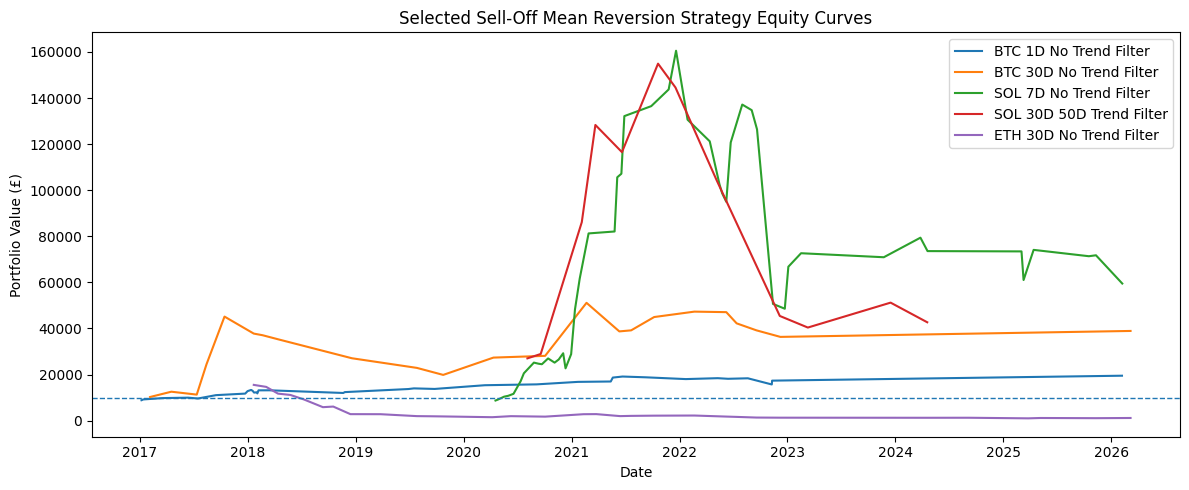

In [21]:
selected_strategies = [
    ("BTC", 1, "No Trend Filter"),
    ("BTC", 30, "No Trend Filter"),
    ("SOL", 7, "No Trend Filter"),
    ("SOL", 30, "50D Trend Filter"),
    ("ETH", 30, "No Trend Filter")
]

plt.figure(figsize=(12, 5))

for asset_name, holding_period, filter_type in selected_strategies:
    trades = trade_logs[(asset_name, holding_period, filter_type)]

    if len(trades) > 0:
        label = f"{asset_name} {holding_period}D {filter_type}"
        plt.plot(trades["Exit Date"], trades["Portfolio Value"], label=label)

plt.axhline(starting_capital, linestyle="--", linewidth=1)

plt.title("Selected Sell-Off Mean Reversion Strategy Equity Curves")
plt.ylabel("Portfolio Value (£)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Buy-And-Hold Equity Curves

This chart shows how £10,000 would have grown if invested into each asset at the first available date and held until the end of the sample period.

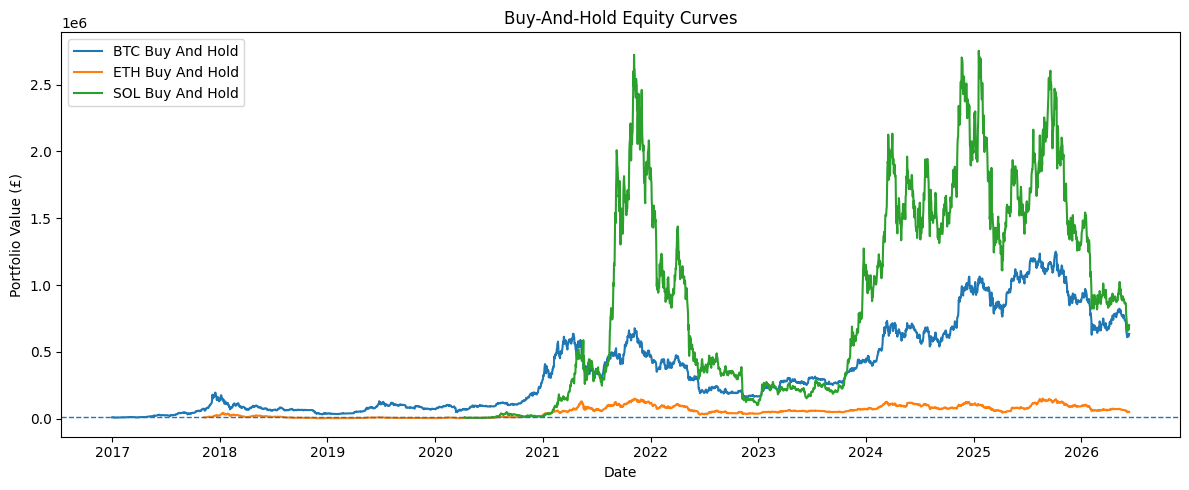

In [22]:
plt.figure(figsize=(12, 5))

for asset_name, data in asset_data.items():
    clean_data = data.dropna(subset=["Close"]).copy()
    buy_and_hold_equity = starting_capital * (clean_data["Close"] / clean_data["Close"].iloc[0])

    plt.plot(clean_data.index, buy_and_hold_equity, label=f"{asset_name} Buy And Hold")

plt.axhline(starting_capital, linestyle="--", linewidth=1)

plt.title("Buy-And-Hold Equity Curves")
plt.ylabel("Portfolio Value (£)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

## Benchmark And Risk-Adjusted Findings

The buy-and-hold benchmark shows that simply holding BTC and SOL over the full sample period produced much higher total returns than the sell-off mean-reversion strategy. However, these buy-and-hold returns came with very large maximum drawdowns, showing that passive exposure to crypto assets involved substantial downside risk.

The buy-and-hold benchmark is not a perfect like-for-like comparison because it assumes the investor bought each asset at the first available date in the dataset and remained invested throughout the full sample period. This naturally favours assets that experienced large long-term bull markets, especially when the dataset begins early in the asset’s trading history.

The sell-off strategy, by contrast, is only invested after specific -10% daily sell-off signals. It therefore has much lower market exposure and should be interpreted as a tactical strategy rather than a direct replacement for buy-and-hold.

The risk-adjusted ranking provides a more useful comparison than raw return alone. BTC strategies, especially those using the 50-day moving average filter, produced some of the strongest return-to-drawdown scores. This suggests that BTC offered cleaner and more controlled mean-reversion opportunities than ETH or SOL under the rules tested.

SOL produced the strongest raw strategy returns, particularly over 3-day, 7-day and 30-day holding periods. However, these returns came with much larger drawdowns, making SOL a higher-risk version of the strategy.

Overall, the benchmark comparison suggests that the sell-off strategy was not a replacement for buy-and-hold during strong crypto bull markets. Instead, it behaved more like a tactical strategy that attempted to capture rebounds after extreme daily declines while reducing continuous market exposure.

## Limitations

This backtest is a simplified historical analysis and has several important limitations.

First, the strategy enters at the signal-day close. In live trading, an investor may not know the final daily return until the close has occurred, meaning the exact closing price may not be achievable in practice.

Second, the backtest uses daily price data rather than intraday data. This means it does not capture intraday price movements, liquidity conditions, spreads or execution timing.

Third, the transaction cost assumption is simplified. The model applies a fixed transaction cost, but real trading costs can vary depending on exchange fees, bid-ask spreads, slippage, volatility and order size.

Fourth, the buy-and-hold benchmark is not a perfect like-for-like comparison because it assumes continuous exposure from the first available date in each asset’s dataset. This can favour assets that experienced large long-term bull markets from early in their trading history.

Fifth, the strategy does not include advanced risk management rules such as stop losses, take profits, volatility-adjusted position sizing or portfolio diversification.

Finally, the results are based on historical data and should not be interpreted as evidence that the same strategy will work in the future.


## Possible Improvements

This project could be extended in several ways.

A more realistic version of the backtest could enter trades on the next day’s open rather than the signal-day close. This would better reflect the difficulty of trading exactly at the closing price after a sell-off has been confirmed.

The strategy could also be tested using intraday data to better understand execution timing, volatility and slippage around large sell-off events.

Future versions could add risk management rules such as stop losses, take-profit levels, volatility-adjusted position sizing or maximum portfolio exposure limits.

The analysis could also compare the strategy against a benchmark using the same start date across all assets. This would make the buy-and-hold comparison fairer, especially because BTC, ETH and SOL have different available data histories.

Finally, the strategy could be expanded into a portfolio backtest that allocates capital across BTC, ETH and SOL rather than testing each asset separately.


## Final Conclusion

This project tested whether a simple sell-off mean-reversion strategy could produce attractive historical returns across BTC, ETH and SOL.

The results show that the strategy behaved very differently across assets. BTC produced the cleanest and most controlled mean-reversion profile, particularly over shorter holding periods and when using the 50-day moving average filter. These BTC strategies did not always produce the highest raw returns, but they performed well on a return-to-drawdown basis.

SOL produced the strongest raw strategy returns, especially over 3-day, 7-day and 30-day holding periods. However, these returns came with much larger drawdowns and more severe worst-trade outcomes, making SOL a higher-risk version of the strategy.

ETH was the weakest asset under this framework. Several ETH strategies, particularly those using longer holding periods, produced negative total returns and weak risk-adjusted results.

The buy-and-hold benchmark produced much higher raw returns for BTC and SOL, but this reflected continuous exposure from early in each asset’s available price history and came with very large drawdowns. The sell-off strategy should therefore be viewed as a tactical mean-reversion approach rather than a direct replacement for buy-and-hold.

Overall, the backtest suggests that large crypto sell-offs have historically created some short-term rebound opportunities, but the quality of those opportunities depends heavily on the asset, holding period, trend environment and drawdown risk.
